# Домашнее задание 5. Анализ данных на Spark SQL

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
pip install pyspark findspark

Note: you may need to restart the kernel to use updated packages.


In [13]:
import findspark
findspark.init()

import warnings
warnings.filterwarnings('ignore')

import pyspark
from pyspark.context import SparkContext, SparkConf
from pyspark.sql.types import DecimalType
from pyspark.sql.functions import avg, count, col, sum
from pyspark.sql.session import SparkSession
from pyspark.sql import functions as f

spark = (
    SparkSession
    .builder
    .appName('Homework_05')
    .config('spark.ui.port', '9311')
    .config('spark.executor.memoryOverhead', '1G')
    .config('spark.shuffle.service.enabled', 'true')
    .config('spark.dynamicAllocation.enabled', 'true')
    .config('spark.driver.extraClassPath', '/opt/spark/jars/sqljdbc42.jar')\
    .config('spark.executor.extraClassPath', '/opt/spark/jars/sqljdbc42.jar')\
    .getOrCreate()
)

In [4]:
spark

### Шаг 1. Создать таблицу, используя csv-файл.

In [5]:
df = spark.read.option("header",True).option("sep",",").csv("data_to_insert/Hotel.csv")
df.show(5,0)

+--------+--------+----------+--------------+-----------+------------+-----------------+-----------+---------+----+-----+----+--------------+--------------+----------------------+------------------------------+--------------+----------------+------------+
|ID      |n_adults|n_children|weekend_nights|week_nights|meal_plan   |car_parking_space|room_type  |lead_time|year|month|date|market_segment|repeated_guest|previous_cancellations|previous_bookings_not_canceled|avg_room_price|special_requests|status      |
+--------+--------+----------+--------------+-----------+------------+-----------------+-----------+---------+----+-----+----+--------------+--------------+----------------------+------------------------------+--------------+----------------+------------+
|INN00001|2       |0         |1             |2          |Meal Plan 1 |0                |Room_Type 1|224      |2017|10   |2   |Offline       |0             |0                     |0                             |65            |0      

### Шаг 2. Создать (сгенерировать) таблицу calendar, который будет состоять из одного поля calendar_dt со всеми днями с 2017-01-01 по 2018-12-31.

In [6]:
calendar_dt = spark.sql("""
    SELECT 
        explode(sequence(to_date('2017-01-01')
        , to_date('2018-12-31')
        , interval 1 day)) as calendar_dt
""")

calendar_dt.show(10)

+-----------+
|calendar_dt|
+-----------+
| 2017-01-01|
| 2017-01-02|
| 2017-01-03|
| 2017-01-04|
| 2017-01-05|
| 2017-01-06|
| 2017-01-07|
| 2017-01-08|
| 2017-01-09|
| 2017-01-10|
+-----------+
only showing top 10 rows


### Шаг 3. Выполнить следующие запросы:

#### 1. Вычислить среднее количество ночей, которые гости проводят в отеле (только для подтвержденных бронирований, с детализацией по месяцам и годам)

In [7]:
avg_nights = df \
    .filter(f.col('status') == 'Not_Canceled') \
    .withColumn("total_nights", f.col("weekend_nights").cast("int") + f.col("week_nights").cast("int")) \
    .groupBy("year", "month")\
    .agg(f.round(avg("total_nights"), 2).alias("avg_nights")) \
    .orderBy(f.col("year").cast("int"), f.col("month").cast("int"))

avg_nights.show(10)

+----+-----+----------+
|year|month|avg_nights|
+----+-----+----------+
|2017|    7|      3.02|
|2017|    8|      2.72|
|2017|    9|      2.66|
|2017|   10|       2.7|
|2017|   11|      2.72|
|2017|   12|      3.04|
|2018|    1|      2.74|
|2018|    2|      2.69|
|2018|    3|      3.04|
|2018|    4|      2.92|
+----+-----+----------+
only showing top 10 rows


#### 2. Определить ТОП-3 месяца по проценту отмененных броней за 2018 год.

In [8]:
grouped_by_month_status = df \
    .filter(f.col('year') == 2018) \
    .groupBy("month", "status")\
    .agg(count("*").alias("count_booking"))

left = grouped_by_month_status \
    .filter(f.col('status') == 'Canceled')

right = grouped_by_month_status \
    .groupBy("month") \
    .agg(sum("count_booking").alias("total_count_booking"))        

top_3_canceled = left.join(right, ['month', 'month'], 'inner') \
    .withColumn("percent_of_canceled", f.round(f.col("count_booking") * 100 / f.col("total_count_booking"), 2)) \
    .orderBy(f.col("percent_of_canceled").desc()) \
    .select("month", "percent_of_canceled") \
    .limit(3)

top_3_canceled.show(10)

+-----+-------------------+
|month|percent_of_canceled|
+-----+-------------------+
|    8|              46.55|
|   10|              46.36|
|    9|              45.78|
+-----+-------------------+



#### 3. Вычислить среднее время на каждый месяц между бронированием и заездом в отель для подтвержденных броней.

In [9]:
grouped_by_month_avg_lead_time = df \
    .filter(f.col('status') == 'Not_Canceled') \
    .groupBy("month") \
    .agg(f.round(avg("lead_time"), 2).alias("avg_lead_time")) \
    .orderBy(f.col("month").cast("int"))

grouped_by_month_avg_lead_time.show(20)

+-----+-------------+
|month|avg_lead_time|
+-----+-------------+
|    1|        34.87|
|    2|        30.53|
|    3|        43.19|
|    4|        62.49|
|    5|        60.99|
|    6|        70.64|
|    7|        90.16|
|    8|        65.97|
|    9|        57.78|
|   10|        65.11|
|   11|        41.02|
|   12|        61.79|
+-----+-------------+



#### 4. Вычислить общую среднюю выручку на каждый месяц в каждом году, сгруппировав по всем типам бронирования для подтвержденных броней, и вывести это в виде сводной таблицы (PIVOT).

In [10]:
pivot_df = df \
    .filter(f.col('status') == 'Not_Canceled') \
    .withColumn("total_avg_sum", 
                (f.col("weekend_nights").cast("int") + f.col("week_nights").cast("int")) 
                * f.col("avg_room_price").cast("float")) \
    .groupBy("year", "month") \
    .pivot("market_segment") \
    .agg(f.round(avg("total_avg_sum"), 2).alias("avg_total_avg_sum")) \
    .orderBy(f.col("year").cast("int"), f.col("month").cast("int")) \
    .fillna(0.0)

pivot_df.show()

+----+-----+--------+-------------+---------+-------+------+
|year|month|Aviation|Complementary|Corporate|Offline|Online|
+----+-----+--------+-------------+---------+-------+------+
|2017|    7|     0.0|         22.4|   113.75| 228.95|290.56|
|2017|    8|     0.0|         0.32|   156.42| 235.54|284.21|
|2017|    9|     0.0|        16.89|   177.83| 236.65|348.55|
|2017|   10|     0.0|         1.09|   180.26| 223.24|311.47|
|2017|   11|     0.0|        14.81|   102.97| 198.36|240.52|
|2017|   12|     0.0|         0.25|   141.11| 253.86|258.93|
|2018|    1|     0.0|         2.27|   113.03| 210.51|236.09|
|2018|    2|   352.0|         1.39|   115.06| 251.85|238.07|
|2018|    3|  118.33|        38.17|   142.39| 233.39|301.71|
|2018|    4|  321.81|          0.0|   108.42| 236.44|320.08|
|2018|    5|   262.5|          0.0|    229.5| 274.55|352.34|
|2018|    6|   247.0|          0.0|   148.13| 251.98|335.03|
|2018|    7|    79.0|         5.38|   146.99| 310.36|390.05|
|2018|    8|     0.0|   

#### 5. Выявить ТОП-5 постоянных гостей, которые принесли наибольшую выручку за все время, и показать их долю в общей выручке от постоянных гостей. Использовать уникальный идентификатор брони как уникальный идентификатор гостя, предположив, что 1 бронь = 1 гость.

In [11]:
df_with_booking_sum = df \
    .filter((f.col('status') == 'Not_Canceled') & (f.col('repeated_guest') == True)) \
    .withColumn("booking_sum", 
                f.round((f.col("weekend_nights").cast("int") + f.col("week_nights").cast("int")) 
                * f.col("avg_room_price").cast("float"), 2))

total_sum = df_with_booking_sum.agg(f.sum("booking_sum")).collect()[0][0]    

top_5 = df_with_booking_sum \
    .withColumn("total_sum", f.lit(total_sum)) \
    .orderBy(f.col("booking_sum").desc()) \
    .withColumn("fraction", f.round((f.col("booking_sum") / f.col("total_sum")).cast(DecimalType(38, 16)), 5)) \
    .select("id", "booking_sum", "fraction") \
    .limit(5)

top_5.show()

+--------+-----------+--------+
|      id|booking_sum|fraction|
+--------+-----------+--------+
|INN19235|     1754.4| 0.01550|
|INN05222|      690.0| 0.00610|
|INN14189|      665.0| 0.00588|
|INN09923|      660.0| 0.00583|
|INN25479|      650.0| 0.00574|
+--------+-----------+--------+



#### 6. Вывести общее количество гостей на каждый день в отеле, отсортировав по убыванию дат, включая дни, когда отель пустует. Также рассчитать процент загрузки для каждого дня, если известно, что общая вместимость отеля 400 человек

**Возникла необходимость удалить несуществующую дату, а именно 29.02.2018 во избежание следующей ошибки:**
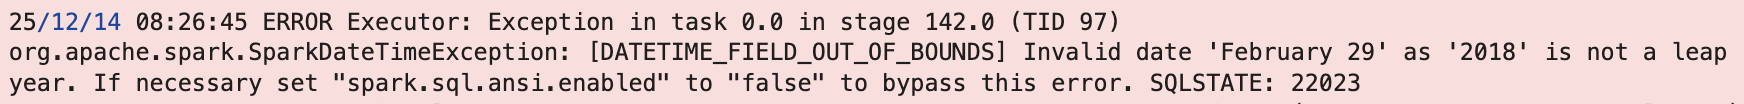

In [14]:
person_count_df = df \
    .filter(f.col('status') == 'Not_Canceled') \
    .filter(~((f.col('year').cast("int") == 2018) & 
              (f.col('month').cast("int") == 2) & 
              (f.col('date').cast("int") == 29))) \
    .withColumn("person_count", 
                f.col("n_adults").cast("int") + f.col("n_children").cast("int")) \
    .withColumn("full_date", 
                f.make_date(f.col("year").cast("int"), f.col("month").cast("int"), f.col("date").cast("int")))

total_guest_count = calendar_dt \
    .join(person_count_df, calendar_dt.calendar_dt == person_count_df.full_date, 'left') \
    .groupBy("calendar_dt") \
    .agg(f.coalesce(f.sum("person_count"), f.lit(0)).alias("total_persons")) \
    .select("calendar_dt", "total_persons") \
    .withColumn("load_percentage", f.round((f.col("total_persons") * 100 / 400.0), 2)) \
    .orderBy(f.col("calendar_dt").desc())
    
total_guest_count.show(100)

+-----------+-------------+---------------+
|calendar_dt|total_persons|load_percentage|
+-----------+-------------+---------------+
| 2018-12-31|           67|          16.75|
| 2018-12-30|          166|           41.5|
| 2018-12-29|          162|           40.5|
| 2018-12-28|          134|           33.5|
| 2018-12-27|          263|          65.75|
| 2018-12-26|          117|          29.25|
| 2018-12-25|           84|           21.0|
| 2018-12-24|           98|           24.5|
| 2018-12-23|          113|          28.25|
| 2018-12-22|           89|          22.25|
| 2018-12-21|           91|          22.75|
| 2018-12-20|           64|           16.0|
| 2018-12-19|           68|           17.0|
| 2018-12-18|           83|          20.75|
| 2018-12-17|           82|           20.5|
| 2018-12-16|          124|           31.0|
| 2018-12-15|           53|          13.25|
| 2018-12-14|           44|           11.0|
| 2018-12-13|           54|           13.5|
| 2018-12-12|           51|     